# <font color="darkgreen">Facultad de Ingeniería en Ciencias de la Tierra (FICT)</font>

# <font color="midnightblue">Bases de programación</font>
## <font color="midnightblue">Proyecto: Automatización de Análisis y Visualización de Datos Climáticos </font>
***

### Integrantes
1. RAMÍREZ LÓPEZ ASTRID ISABEL
2. ROSADO ZAMBRANO VICTORIA MICHELLE
3. VACA MOLINA VALERIA PAULETTE
***

## <font color="firebrick">1. Introducción </font>


El crecimiento en la disponibilidad de datos ha incrementado la necesidad de desarrollar procesos automatizados que permitan su almacenamiento, depuración, análisis e interpretación de manera eficiente. En este contexto, el lenguaje de programación Python y la biblioteca Pandas se han consolidado como herramientas ampliamente utilizadas para la manipulación y análisis de datos, debido a que proporcionan estructuras flexibles y funciones optimizadas para el tratamiento de grandes volúmenes de información (McKinney, 2022).

La estructura fundamental de Pandas es el DataFrame, una tabla bidimensional compuesta por filas y columnas que facilita la organización, transformación y análisis de datos de distintos tipos. Esta estructura permite realizar operaciones como la limpieza de registros, conversión de tipos de datos, agrupamiento, filtrado, cálculo de estadísticas descriptivas y generación de nuevas variables de forma eficiente y reproducible (McKinney, 2022; Pandas Development Team, 2025).

En este proyecto se aplicaron técnicas de programación mediante el uso de funciones y estructuras iterativas para automatizar el análisis de un conjunto de datos climáticos. El desarrollo comprendió la carga y preparación de la información, la eliminación de registros duplicados, la conversión de tipos de datos, la implementación de funciones para el cálculo de estadísticas descriptivas, la creación de una nueva variable correspondiente a la sensación térmica, el análisis exploratorio de datos (EDA), la manipulación de información mediante operaciones de agrupamiento y agregación con Pandas, y la generación automatizada de visualizaciones para identificar patrones y tendencias en las variables meteorológicas.

La automatización de estas tareas contribuye a mejorar la eficiencia del procesamiento, reduce la repetición de código y favorece la reproducibilidad de los análisis, aspectos fundamentales en proyectos de ciencia de datos y análisis estadístico. Asimismo, el empleo de funciones reutilizables permite adaptar fácilmente el flujo de trabajo a nuevos conjuntos de datos con características similares, optimizando el tiempo de desarrollo y facilitando futuras aplicaciones.

## <font color="firebrick">2. Objetivo del proyecto.</font>


El objetivo del proyecto es automatizar el proceso de carga, limpieza, análisis y visualización de un conjunto de datos climáticos mediante el uso de bucles y funciones, para mejorar la eficiencia y la reproducibilidad del análisis de la información. 

## <font color="firebrick">3. Descripción del conjunto de datos</font>


El conjunto de datos analizado corresponde a registros de información climática almacenados en un archivo CSV denominado Weather_Data-1.csv. La base de datos está conformada por 1 000 000 registros y 6 variables, las cuales describen diferentes condiciones meteorológicas registradas durante el período comprendido entre enero y mayo de 2024.

Las variables incluidas son:

**Location:** ciudad donde se registró la información climática (variable categórica).

**Date_Time:** fecha y hora del registro meteorológico.

**Temperature_C:** temperatura del aire expresada en grados Celsius (°C).

**Humidity_pct:** humedad relativa del ambiente, expresada en porcentaje (%).

**Precipitation_mm:** precipitación registrada, expresada en milímetros (mm).

**Wind_Speed_kmh:** velocidad del viento, expresada en kilómetros por hora (km/h).

## <font color="firebrick">4. Análisis exploratorio de datos (EDA)</font>


El análisis exploratorio de datos fue realizado siguiendo 10 pasos que se encuentran en la Figura 1.

![Picture_title](eda.png)
*Figura 1: Pasos del análisis exploratorio de datos* 

### 4.1. Importación de librerias

In [1]:
import pandas as pd
import numpy as nd
import seaborn as sns
import matplotlib.pyplot as plt

### 4.2. EDA – 1. Explorar filas

In [2]:
#Visualización incial de datos
archivo_csv = "Weather_Data-1.csv"
df = pd.read_csv(archivo_csv, sep=",") 

print("\nEstado inicial del dataframe\n")
display(df.head())
print(f" El dataframe que contiene información del clima posee {df.shape[0]} filas y {df.shape[1]} columnas\n")
df.info()


Estado inicial del dataframe



,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,1/14/2024 21:12,10.683001,41.195754,4.020119,8.233540
1,San Diego,5/17/2024 15:22,8.734140,58.319107,9.111623,27.715161
2,San Diego,5/11/2024 9:30,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2/26/2024 17:32,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,4/29/2024 13:23,39.808213,72.899908,9.598282,29.898622


 El dataframe que contiene información del clima posee 1000000 filas y 6 columnas

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Location          1000000 non-null  str    
 1   Date_Time         1000000 non-null  str    
 2   Temperature_C     1000000 non-null  float64
 3   Humidity_pct      1000000 non-null  float64
 4   Precipitation_mm  1000000 non-null  float64
 5   Wind_Speed_kmh    1000000 non-null  float64
dtypes: float64(4), str(2)
memory usage: 45.8 MB


In [3]:
#Aplicación de función para realizar la limpieza de datos
def limpiar_datos(df):  
    
    # Limpieza básica: eliminar duplicados
    duplicados_antes = df.duplicated().sum()
    df = df.drop_duplicates()

    # Modificar tipo de datos: Convertir Date_Time a objeto datetime
    df['Date_Time'] = pd.to_datetime(df['Date_Time'])

    
    print(f"\n--- Carga y Limpieza Completada ---\n")
    print(f"Registros duplicados eliminados: {duplicados_antes}")
    print(f"Dimensión final del DataFrame: {df.shape}")
    
    # Identificar si existen nulos en dataframe
    nulos_por_columna = df.isnull().sum()
    
    total_nulos = nulos_por_columna.sum()
 
    if total_nulos > 0:
        print("\nSe encontraron valores nulos por columna:")
        print(nulos_por_columna[nulos_por_columna > 0])
        df = df.dropna()
        print(f"-> Se eliminaron las filas con valores faltantes.")
    else:
        print("No se detectaron valores nulos en el conjunto de datos.")
    return df

# Carga de los datos climáticos y aplicar la depuración con la función
df_clima = limpiar_datos(df)

# Primeras 5 filas del dataframe
print("Visualización de del dataframe después de depuración:")
display(df_clima.head())


--- Carga y Limpieza Completada ---

Registros duplicados eliminados: 0
Dimensión final del DataFrame: (1000000, 6)
No se detectaron valores nulos en el conjunto de datos.
Visualización de del dataframe después de depuración:


,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,2024-01-14 21:12:00,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:00,8.734140,58.319107,9.111623,27.715161
2,San Diego,2024-05-11 09:30:00,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2024-02-26 17:32:00,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,2024-04-29 13:23:00,39.808213,72.899908,9.598282,29.898622


### 4.3 EDA – 2. Información de columnas

In [4]:
#Crear nuevas columnas derivadas de los datos existentes (e.g., calcular la sensación térmica a partir de la temperatura y la humedad)
#Fuente (NOOA)
def heat_index(df):
    
    # Convertir °C a °F
    T = (df['Temperature_C'] * 9/5) + 32
    RH = df['Humidity_pct']

    # Fórmula simple
    HI = 0.5 * (T + 61 + ((T - 68) * 1.2) + (RH * 0.094))
    HI = (HI + T) / 2 #Si este resultado es 80 grados Fahrenheit o superior, se aplica la ecuación de regresión completa

    # Si HI >= 80°F, aplicar fórmula completa
    if HI >= 80:
        HI = (
            -42.379
            + 2.04901523 * T
            + 10.14333127 * RH
            - 0.22475541 * T * RH
            - 0.00683783 * (T**2)
            - 0.05481717 * (RH**2)
            + 0.00122874 * (T**2) * RH
            + 0.00085282 * T * (RH**2)
            - 0.00000199 * (T**2) * (RH**2)
        )

        # Ajuste humedad baja
        if RH < 13 and 80 <= T <= 112:
            HI -= ((13 - RH) / 4) * np.sqrt((17 - abs(T - 95)) / 17)

        # Ajuste humedad alta
        elif RH > 85 and 80 <= T <= 87:
            HI += ((RH - 85) / 10) * ((87 - T) / 5)
    
    # Regresar a °C
    return (HI - 32) * 5/9

df_clima['Sensacion_Termica'] = df_clima.apply(heat_index, axis=1)
df_clima.head (10)

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,Sensacion_Termica
0,San Diego,2024-01-14 21:12:00,10.683001,41.195754,4.020119,8.233540,9.782762
1,San Diego,2024-05-17 15:22:00,8.734140,58.319107,9.111623,27.715161,7.960013
2,San Diego,2024-05-11 09:30:00,11.632436,38.820175,4.607511,28.732951,10.748655
3,Philadelphia,2024-02-26 17:32:00,-8.628976,54.074474,3.183720,26.367303,-10.326675
4,San Antonio,2024-04-29 13:23:00,39.808213,72.899908,9.598282,29.898622,73.836010
5,San Diego,2024-01-21 08:54:00,27.341055,49.023236,9.166543,27.473896,27.681112
6,San Jose,2024-01-13 02:10:00,1.881883,65.742325,0.221709,1.073112,0.862058
7,New York,2024-01-25 19:04:00,-6.894766,30.804894,8.027624,16.848337,-8.809551
8,New York,2024-03-29 05:20:00,0.963545,38.819158,3.640129,7.989024,-0.453694
9,San Jose,2024-05-18 09:14:00,-1.607088,82.198701,4.101493,25.647282,-2.586515


In [5]:
#Localidad con mayor sensación térmica según dataset
df_clima.loc[df_clima['Sensacion_Termica'].idxmax()]

Location                     San Antonio
Date_Time            2024-02-07 08:04:00
Temperature_C                  39.985771
Humidity_pct                   89.966717
Precipitation_mm                7.715814
Wind_Speed_kmh                  7.959709
Sensacion_Termica              94.363271
Name: 572668, dtype: object

In [6]:
#Localidad con mayor sensación térmica según dataset
df_clima.loc[df_clima['Sensacion_Termica'].idxmin()]

Location                         Phoenix
Date_Time            2024-01-24 22:23:00
Temperature_C                 -19.950223
Humidity_pct                   42.893965
Precipitation_mm                7.394094
Wind_Speed_kmh                 15.847648
Sensacion_Termica             -22.359952
Name: 152336, dtype: object

In [7]:
# .info() aplicado al nuevo dataframe depurado
df_clima.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 7 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   Location           1000000 non-null  str           
 1   Date_Time          1000000 non-null  datetime64[us]
 2   Temperature_C      1000000 non-null  float64       
 3   Humidity_pct       1000000 non-null  float64       
 4   Precipitation_mm   1000000 non-null  float64       
 5   Wind_Speed_kmh     1000000 non-null  float64       
 6   Sensacion_Termica  1000000 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 53.4 MB


### 4.4. EDA – 3. Estadística Descriptiva 

In [8]:
print("\nEstadíatica descriptiva de variables numéricas:\n")
df_clima.describe()


Estadíatica descriptiva de variables numéricas:



,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,Sensacion_Termica
count,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2024-03-10 10:40:29.383979,14.779705,60.021830,5.109639,14.997598,16.737895
min,2024-01-01 00:00:00,-19.969311,30.000009,0.000009,0.000051,-22.359952
25%,2024-02-04 16:28:00,2.269631,45.008500,2.580694,7.490101,1.190561
50%,2024-03-10 11:43:00,14.778002,60.018708,5.109917,14.993777,14.333386
75%,2024-04-14 03:51:00,27.270489,75.043818,7.613750,22.514110,28.101894
max,2024-05-18 19:44:00,39.999801,89.999977,14.971583,29.999973,94.363271
std,NaN,14.482558,17.324022,2.947997,8.663556,19.593194


### 4.5. EDA – 4. Validación de datos

In [9]:
print(f"\nEl dataframe clima posee los siguiente datos:\n\n{df_clima.dtypes}")


El dataframe clima posee los siguiente datos:

Location                        str
Date_Time            datetime64[us]
Temperature_C               float64
Humidity_pct                float64
Precipitation_mm            float64
Wind_Speed_kmh              float64
Sensacion_Termica           float64
dtype: object


### 4.6. EDA – 5. Modificación de tipos de datos
*La modificación del tipo de datos se realizó dentro de la función "limpiar_datos" (sección 4.2), donde se transformó la columna Date_Time en un objeto de tipo datetime.*

### 4.7. EDA – 6. Validación de datos categóricos

In [23]:
#Creación de una validacion de una lista creada dentro de una función "validación_ciudades"
def validacion_ciudades(df, lista_mixta):
    #Recorrido de la variable iteradora en la lista_mixta
    for ciudad in lista_mixta:
        if df['Location'].isin([ciudad]).any():
            print(f"{ciudad}: Pertenece a la columna 'Location'")
        else:
            print(f"{ciudad}: ¡No Pertenece a la columna 'Location'")

#Lista mixta de ciudades
lista_mixta = ['Phoenix', 'Madrid', 'Chicago', 'Philadelphia', 'Quito', 'Houston', 'New York', 'San Antonio', 'Dallas', 'Tokio', 'Los Angeles', 'San Jose', 'San Diego']

#Comprobación de existencia
print("\nIniciando verificación de ciudades:\n")
Verificación = validacion_ciudades(df_clima, lista_mixta)


Iniciando verificación de ciudades:

Phoenix: Pertenece a la columna 'Location'
Madrid: ¡No Pertenece a la columna 'Location'
Chicago: Pertenece a la columna 'Location'
Philadelphia: Pertenece a la columna 'Location'
Quito: ¡No Pertenece a la columna 'Location'
Houston: Pertenece a la columna 'Location'
New York: Pertenece a la columna 'Location'
San Antonio: Pertenece a la columna 'Location'
Dallas: Pertenece a la columna 'Location'
Tokio: ¡No Pertenece a la columna 'Location'
Los Angeles: Pertenece a la columna 'Location'
San Jose: Pertenece a la columna 'Location'
San Diego: Pertenece a la columna 'Location'


### 4.8. EDA – 7. Validación de datos numéricos

In [11]:
# Iteramos tanto por categóricas (object) como por numéricas (float64)
for col in df_clima.select_dtypes(include=['str', 'float64']).columns:
    print(f"--- Frecuencia para la columna: {col} ---")
    
    # Si la columna es float, la agrupamos automáticamente en 4 rangos (bins)
    if df_clima[col].dtype == 'float64':
        print(df_clima[col].value_counts(bins=4))
    else:
        # Si es categórica, se cuenta normal
        print(df_clima[col].value_counts())
        
    print("\n")

--- Frecuencia para la columna: Location ---
Location
Phoenix         100209
Chicago         100164
Philadelphia    100122
Houston         100076
New York         99972
San Antonio      99962
Dallas           99936
Los Angeles      99922
San Jose         99863
San Diego        99774
Name: count, dtype: int64


--- Frecuencia para la columna: Temperature_C ---
(-4.977, 10.015]    300215
(10.015, 25.008]    299613
(25.008, 40.0]      295598
(-20.03, -4.977]    104574
Name: count, dtype: int64


--- Frecuencia para la columna: Humidity_pct ---
(75.0, 90.0]      250700
(45.0, 60.0]      249841
(29.939, 45.0]    249835
(60.0, 75.0]      249624
Name: count, dtype: int64


--- Frecuencia para la columna: Precipitation_mm ---
(3.743, 7.486]      373345
(-0.016, 3.743]     363829
(7.486, 11.229]     256634
(11.229, 14.972]      6192
Name: count, dtype: int64


--- Frecuencia para la columna: Wind_Speed_kmh ---
(22.5, 30.0]      250455
(-0.0309, 7.5]    250329
(7.5, 15.0]       249881
(15.0, 22.

### 4.9. EDA – 8. Agrupación de datos

In [12]:
#Agrupación de por Location y con la funcion de agregación ,mean()
df_clima['Mes'] = df_clima["Date_Time"].dt.month_name()
df_clima.groupby('Mes')[['Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']].mean().round(2)

,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
Mes,,,,
April,15.00,60.01,5.00,14.99
February,14.50,60.07,5.25,15.00
January,14.45,60.02,5.26,14.98
March,15.01,59.99,5.00,15.03
May,15.04,60.03,5.01,14.98


### 4.10. EDA – 9. Agregación de Datos no Agrupados 

In [13]:
def estadistica(df,variable):
    numericas= list(df.select_dtypes(include="number").columns)
    diccionario_vacio={}
    for col in numericas:
        if col=="Precipitation_mm":
            diccionario_vacio[col]=["mean", "std","median","sum"]
        else:
            diccionario_vacio[col]=["mean", "std","median"]
    variables_estadisticas=df.groupby(variable).agg(diccionario_vacio).round(2)
    return variables_estadisticas   
estadistica(df_clima,"Location")

Temperature_C               Humidity_pct                \
                      mean    std median         mean    std median   
Location                                                              
Chicago              15.01  14.44  15.00        60.09  17.34  60.11   
Dallas               15.01  14.46  15.05        59.96  17.35  59.94   
Houston              14.94  14.44  14.96        59.97  17.36  59.94   
Los Angeles          15.08  14.48  15.07        60.07  17.31  60.01   
New York             15.01  14.41  14.99        60.04  17.33  59.98   
Philadelphia         15.04  14.41  15.08        60.04  17.27  60.11   
Phoenix              12.79  14.77  12.76        60.05  17.33  60.05   
San Antonio          15.03  14.44  15.11        59.93  17.33  59.88   
San Diego            14.93  14.43  14.84        60.07  17.29  60.16   
San Jose             14.96  14.39  14.97        59.99  17.34  60.01   

             Precipitation_mm                         Wind_Speed_kmh        \
                         mean   std median        sum           mean   std   
Location                                                                     
Chicago                  5.00  2.89   5.00  501136.93          15.00  8.67   
Dallas                   5.00  2.88   5.00  499430.93          15.02  8.65   
Houston                  5.00  2.89   5.00  500155.54          14.99  8.66   
Los Angeles              5.00  2.89   5.00  500058.77          15.04  8.68   
New York                 4.99  2.89   4.99  499165.85          14.99  8.67   
Philadelphia             5.01  2.90   5.03  501467.10          14.99  8.65   
Phoenix                  6.09  3.28   6.09  610020.81          14.98  8.67   
San Antonio              5.01  2.89   5.00  500618.82          14.96  8.67   
San Diego                5.01  2.89   5.01  499527.82          15.04  8.69   
San Jose                 4.99  2.89   4.99  498056.57          14.97  8.65   

                    Sensacion_Termica                
             median              mean    std median  
Location                                             
Chicago       14.97             17.08  19.70  14.56  
Dallas        15.07             17.05  19.66  14.61  
Houston       15.00             16.95  19.62  14.53  
Los Angeles   15.02             17.19  19.79  14.65  
New York      14.98             17.05  19.62  14.56  
Philadelphia  14.97             17.07  19.61  14.64  
Phoenix       14.96             14.06  18.97  12.20  
San Antonio   14.93             17.05  19.62  14.67  
San Diego     15.07             16.96  19.64  14.40  
San Jose      14.97             16.93  19.51  14.54

In [14]:
#Uso de funciones de agregación en datos no agrupados
diccionario_vacio = {}
funciones_agregacion = ['max', 'min', 'mean','std']

for columna in df_clima.select_dtypes(include=['int64', 'float64']).columns:
    metricas = df_clima[columna].agg(funciones_agregacion).round(2).to_dict()
    diccionario_vacio.update({columna: metricas})

print(diccionario_vacio)

{'Temperature_C': {'max': 40.0, 'min': -19.97, 'mean': 14.78, 'std': 14.48}, 'Humidity_pct': {'max': 90.0, 'min': 30.0, 'mean': 60.02, 'std': 17.32}, 'Precipitation_mm': {'max': 14.97, 'min': 0.0, 'mean': 5.11, 'std': 2.95}, 'Wind_Speed_kmh': {'max': 30.0, 'min': 0.0, 'mean': 15.0, 'std': 8.66}, 'Sensacion_Termica': {'max': 94.36, 'min': -22.36, 'mean': 16.74, 'std': 19.59}}


In [15]:
#Realiza análisis específicos al conjunto de datos. Por ejemplo, encontrar el mes con la temperatura promedio más alta, 
#el año con más precipitaciones, o la ciudad que tenga las velocidades de viento más altas

def clima_tendencias(df):
    #Extraer mes de la columna Date_Time
    df['Mes'] = df['Date_Time'].dt.month

    # Mes más caluroso (Promedio)
    temp_mes = df.groupby('Mes')['Temperature_C'].mean()
    mes_caluroso = int(temp_mes.idxmax()) #devuelve el indice
    temp_max = float(temp_mes.max()) #devuelve el valor

    # Mes más lluvioso (Suma acumulada)
    lluvia_mes = df.groupby('Mes')['Precipitation_mm'].sum()
    mes_lluvioso = int(lluvia_mes.idxmax())
    lluvia_max = float(lluvia_mes.max())

    # Ciudad más ventosa (Promedio)
    viento_ciudad = df.groupby('Location')['Wind_Speed_kmh'].mean()
    ciudad_ventosa = str(viento_ciudad.idxmax())
    viento_max = float(viento_ciudad.max())
    
    # Reporte en forma de diccionario
    reporte = {
        'Año': 2024, 
        'Mes_Mas_Caluroso': {'Mes': mes_caluroso, 'Promedio_C': round(temp_max, 2)},
        'Mes_Mas_Lluvioso': {'Mes': mes_lluvioso, 'Total_mm': round(lluvia_max, 2)},
        'Ciudad_Mas_Ventosa': {'Ciudad': ciudad_ventosa, 'Promedio_kmh': round(viento_max, 2)}
    }
    
    return reporte 

#Impresión de resultados
resultado = clima_tendencias(df_clima) 
resultado

{'Año': 2024,
 'Mes_Mas_Caluroso': {'Mes': 5, 'Promedio_C': 15.04},
 'Mes_Mas_Lluvioso': {'Mes': 1, 'Total_mm': 1174627.64},
 'Ciudad_Mas_Ventosa': {'Ciudad': 'San Diego', 'Promedio_kmh': 15.04}}

### 4.11. EDA – 10. Visualización de datos

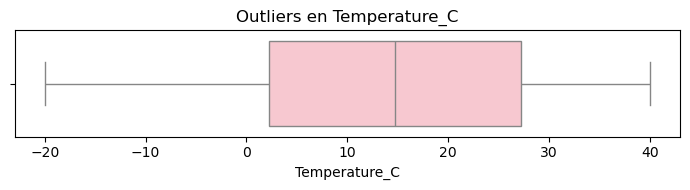

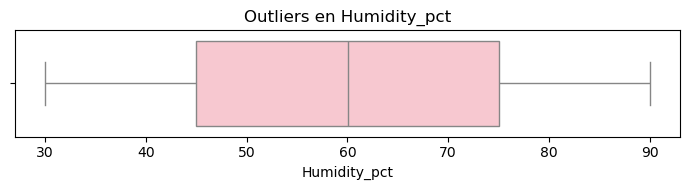

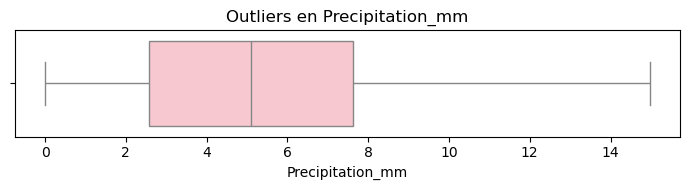

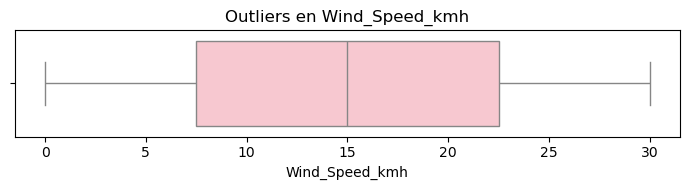

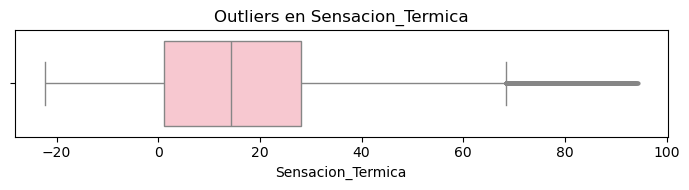

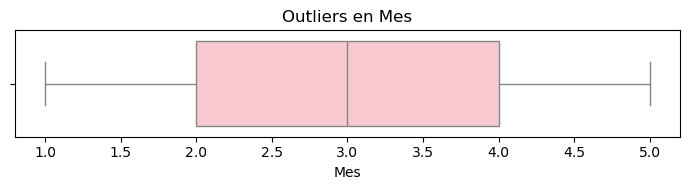

In [16]:
# Filtrar automáticamente solo las columnas que son números (int o float)
columnas_numericas = df_clima.select_dtypes(include=['number']).columns

# Recorrer cada columna y generar su boxplot horizontal
for columna in columnas_numericas:
    plt.figure(figsize=(7, 2))
    
    # x=columna y orient='h' para que sea horizontal
    sns.boxplot(data=df_clima, x=columna, orient='h', color='pink', fliersize=2)
    
    plt.title(f'Outliers en {columna}')
    plt.tight_layout()
    plt.show()

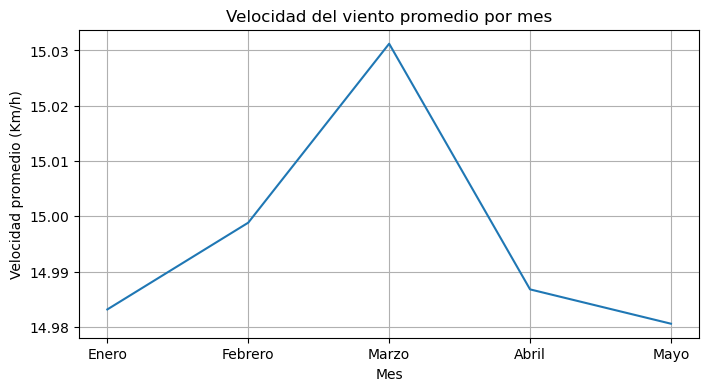

In [17]:
cols_num = ["Enero","Febrero","Marzo", "Abril", "Mayo"]

def velocidad_promedio_mes(df):
    # Calcular la velocidad del viento promedio por mes
    promedio = df.groupby(df["Date_Time"].dt.month)["Wind_Speed_kmh"].mean()
    # Graficar
    plt.figure(figsize=(8,4))
    plt.plot(promedio.index, promedio.values)
    plt.title("Velocidad del viento promedio por mes")
    plt.xlabel("Mes")
    plt.ylabel("Velocidad promedio (Km/h)")
    plt.xticks([1, 2, 3,4,5],cols_num)
    plt.grid(True)
    plt.show()

velocidad_promedio_mes(df_clima)

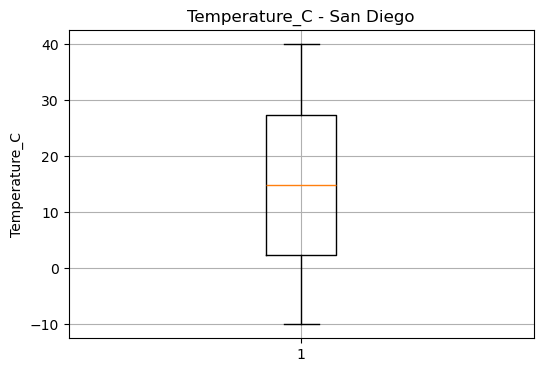

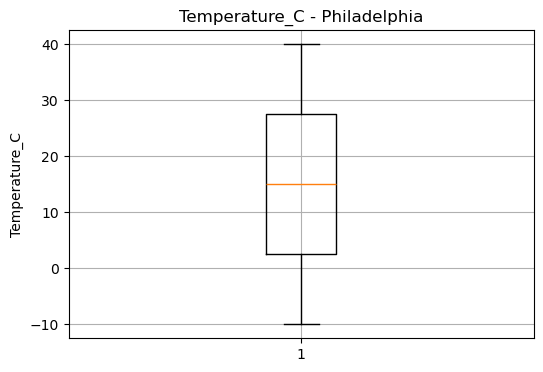

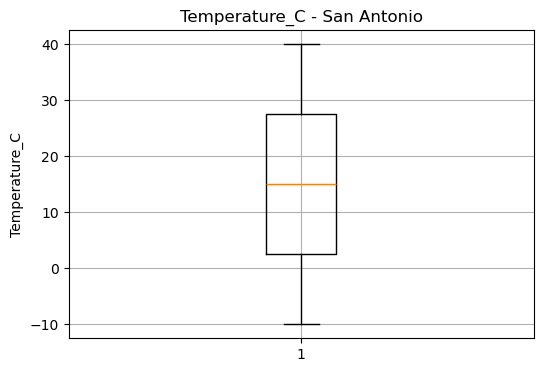

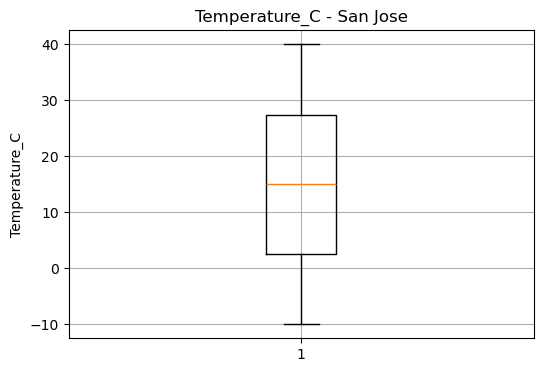

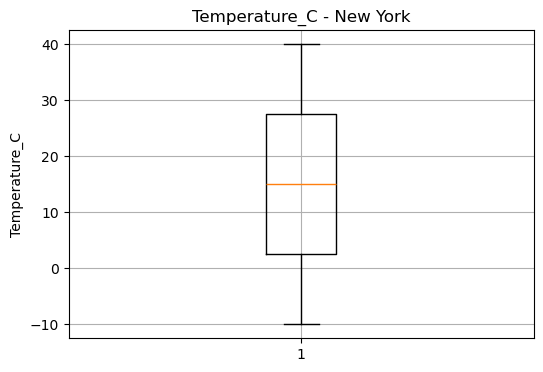

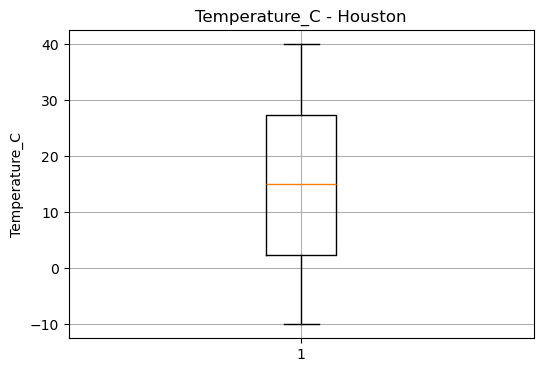

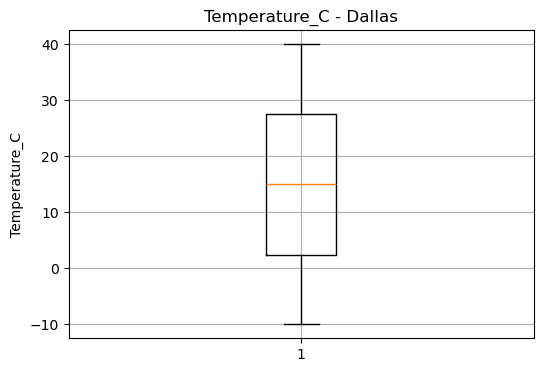

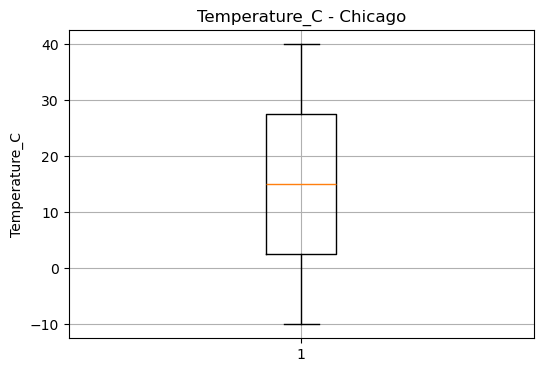

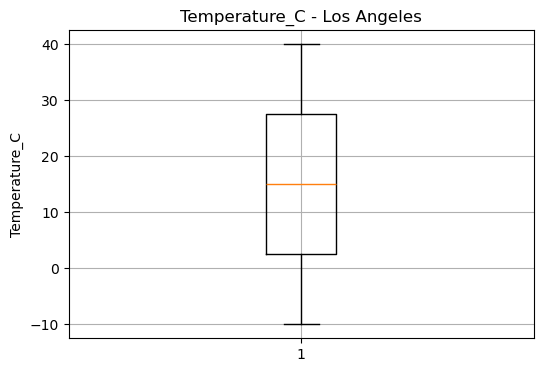

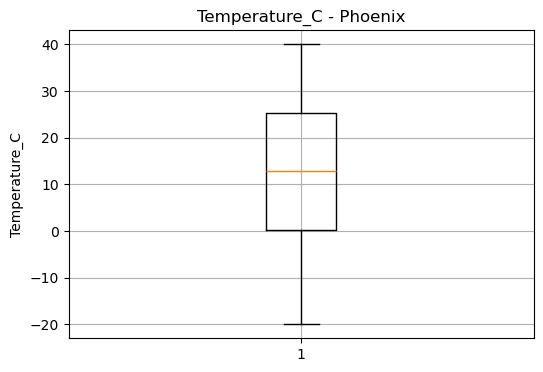

In [18]:
def diagrama_caja(df, location, variable):
# Recorrer cada ciudad de la columna categórica
    for ciudad in df[location].unique():

        # Filtrar los datos de esa ciudad
        datos = df[df[location] == ciudad]

        # Crear gráfico
        plt.figure(figsize=(6, 4))
        plt.boxplot(datos[variable])
        plt.title(f"{variable} - {ciudad}")
        plt.ylabel(variable)
        plt.grid(True)
        plt.show()
    
diagrama_caja(df_clima, "Location", "Temperature_C")

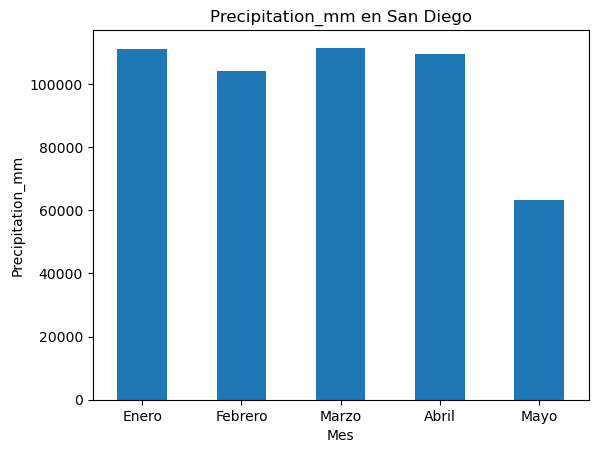

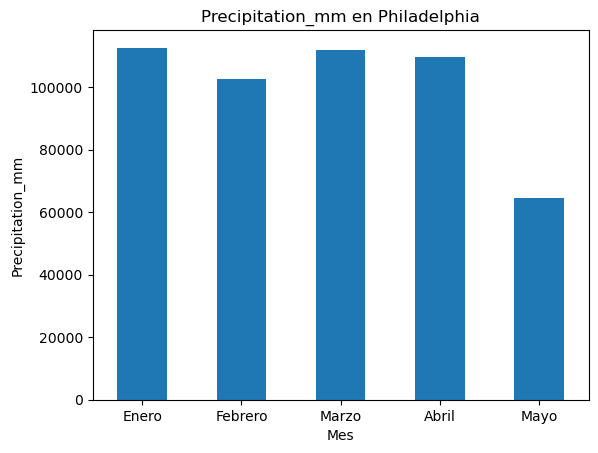

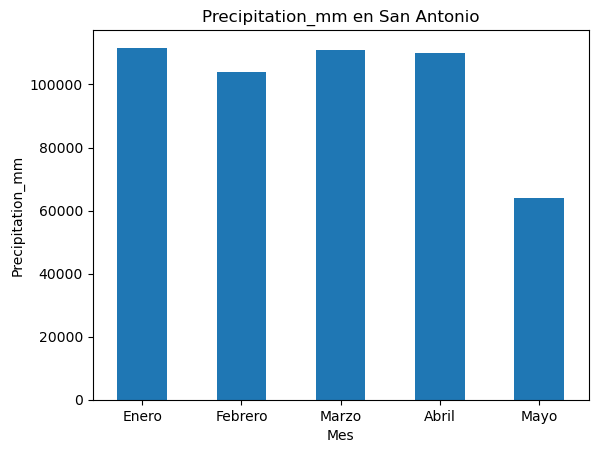

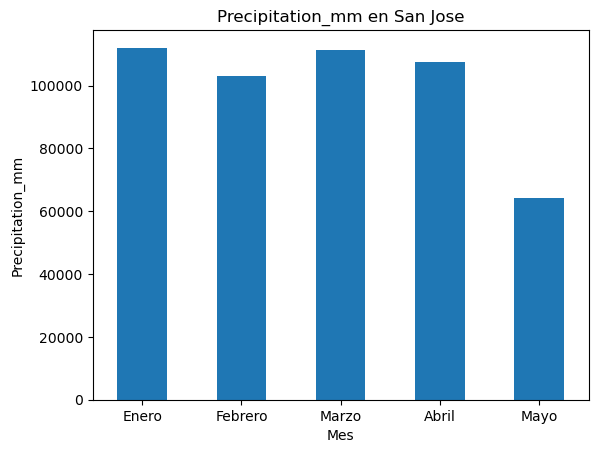

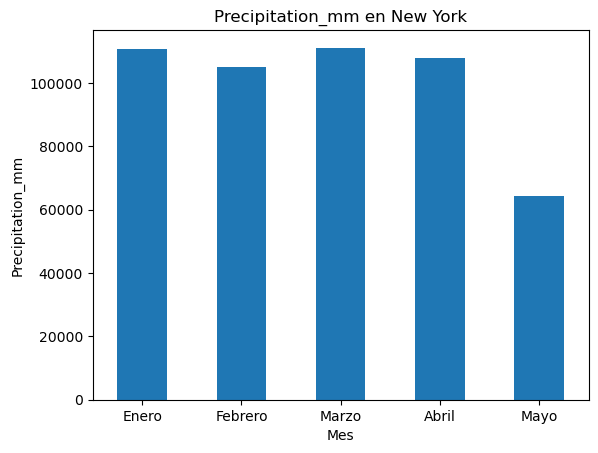

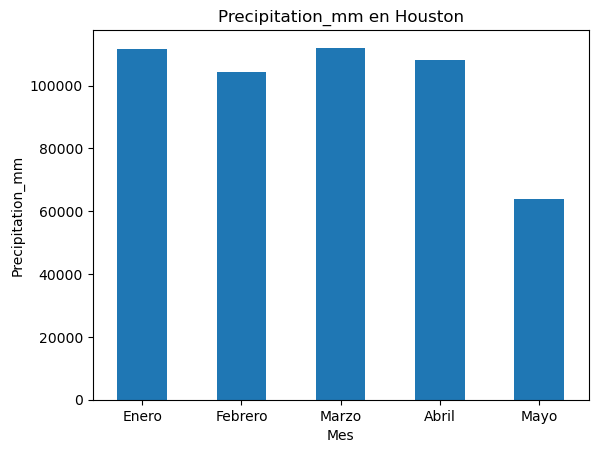

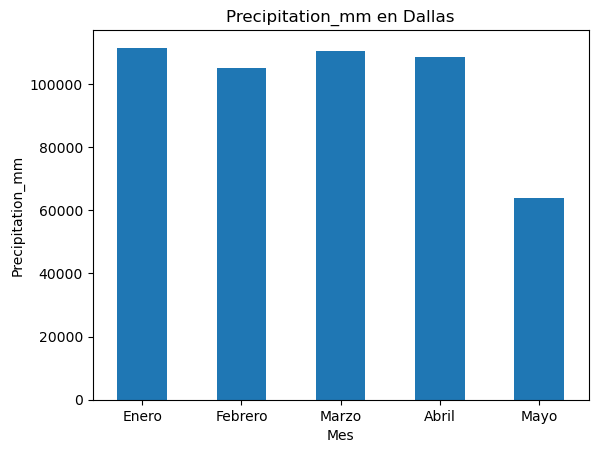

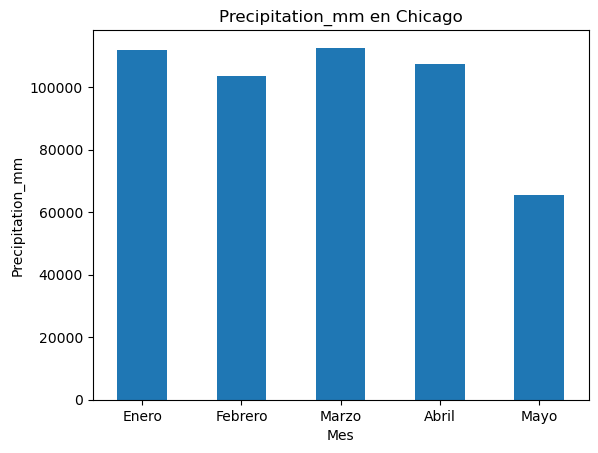

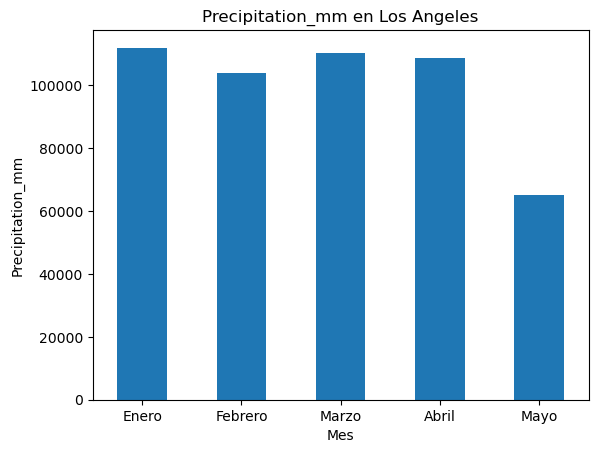

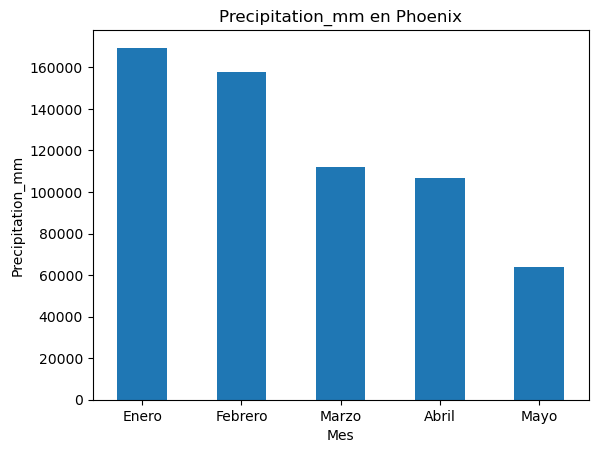

In [19]:
def graficar_barras_meses(df, location, mes, variable):

    # Recorrer cada ciudad
    for ciudad in df[location].unique():

        # Filtrar por ciudad
        datos = df[df[location] == ciudad]

        # Extraer el mes
        datos['Mes'] = datos[mes].dt.month

        # Agrupar por mes y calcular la suma de la variable
        datos.groupby('Mes')[variable].sum().plot(kind='bar')

        # Nombres de los meses
        meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo"]
        plt.xticks(range(len(meses)), meses, rotation=0)

        plt.title(f'{variable} en {ciudad}')
        plt.xlabel('Mes')
        plt.ylabel(variable)
        plt.show()
graficar_barras_meses(df_clima, "Location", 'Date_Time', "Precipitation_mm")

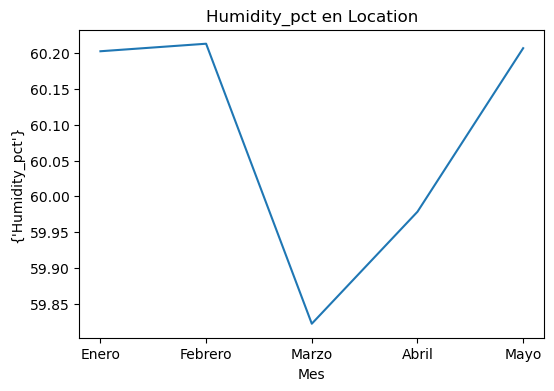

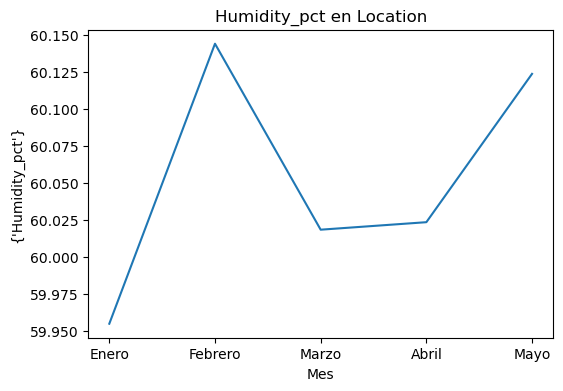

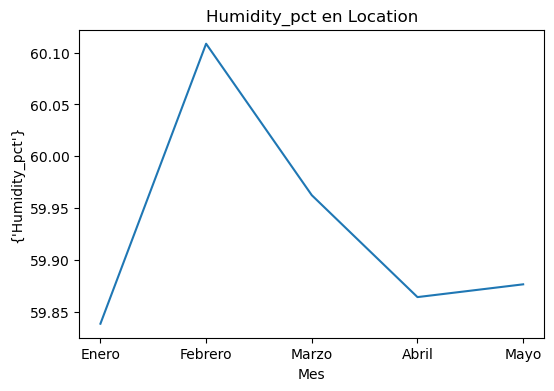

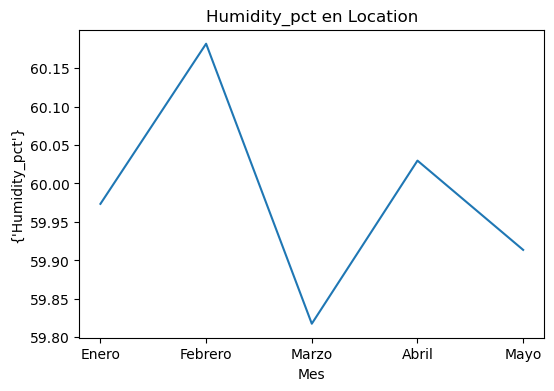

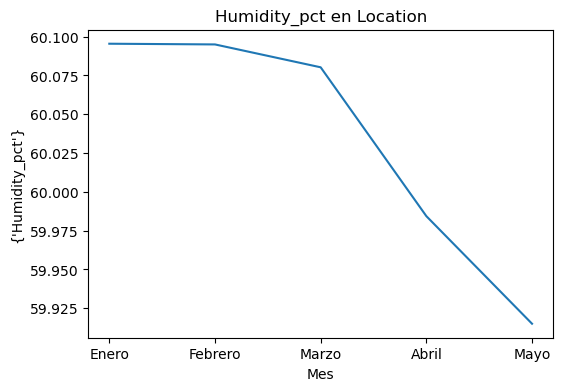

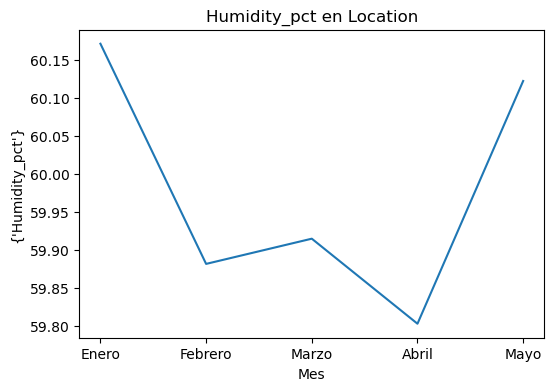

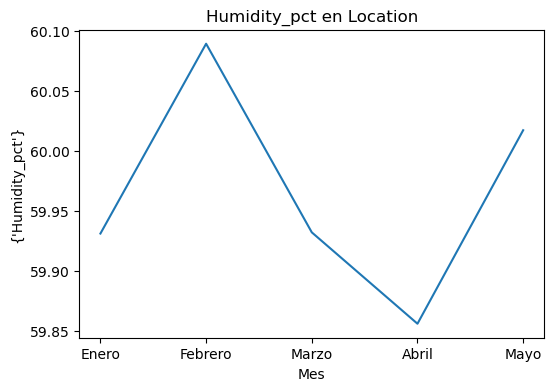

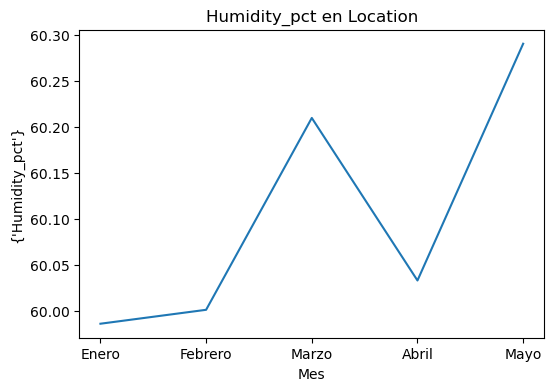

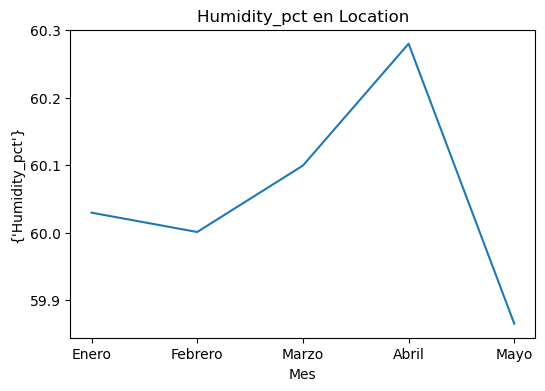

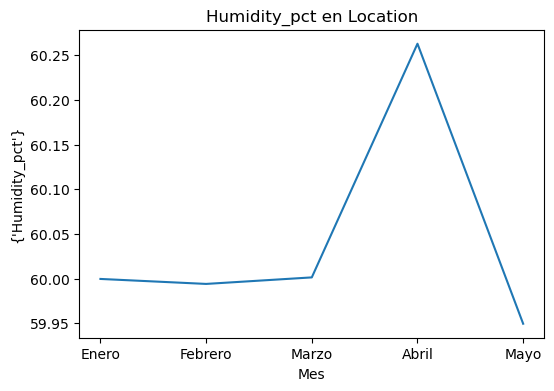

In [20]:
def graficar_barras_meses(df, location, mes, variable):

    # Recorrer cada ciudad
    for ciudad in df[location].unique():

        # Filtrar por ciudad
        datos = df[df[location] == ciudad]

        # Extraer el número del mes
        datos['Mes'] = datos[mes].dt.month

        # Calcular el promedio mensual de la variable
        datos_mes = datos.groupby('Mes')[variable].mean()

        # Graficar
        plt.figure(figsize=(6,4))
        datos_mes.plot(kind='line')
        meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo"]
        plt.xticks(range(1, len (meses) +1), meses, rotation=0) # rotation=0 los deja horizontales
        plt.title(f'{variable} en {location}')
        plt.ylabel({variable})
        plt.show()
        
#LLamar a la función
graficar_barras_meses(df_clima, "Location",'Date_Time', 'Humidity_pct' )

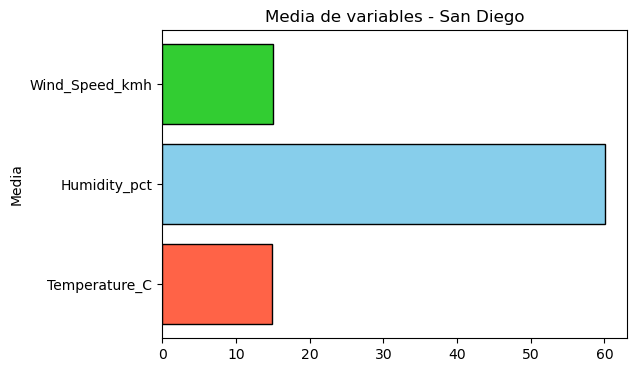

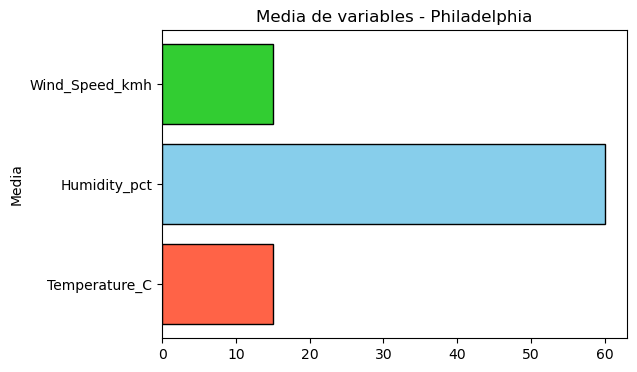

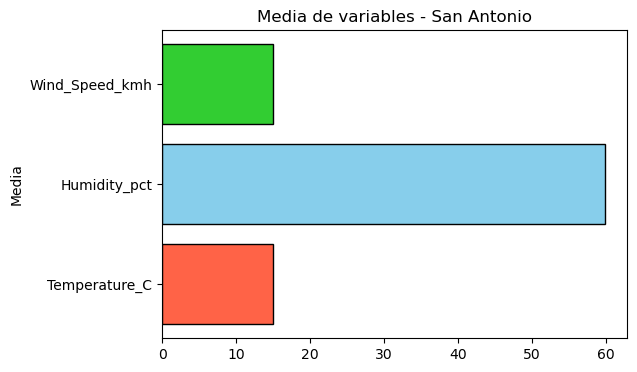

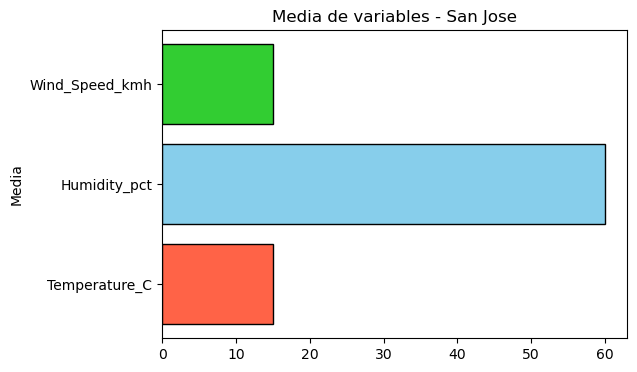

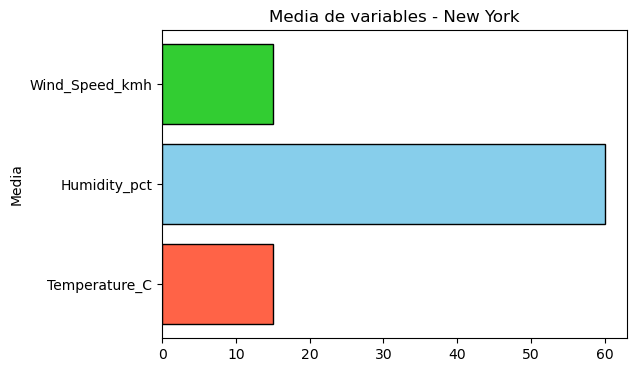

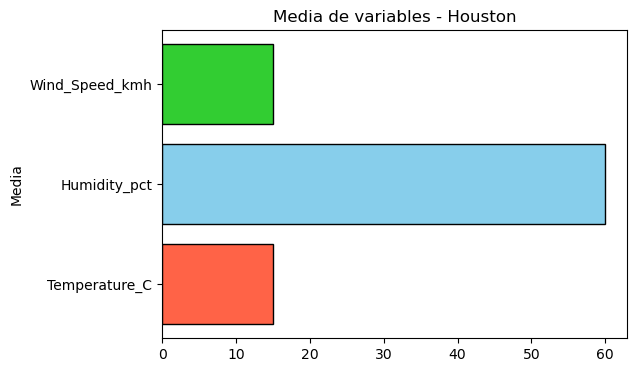

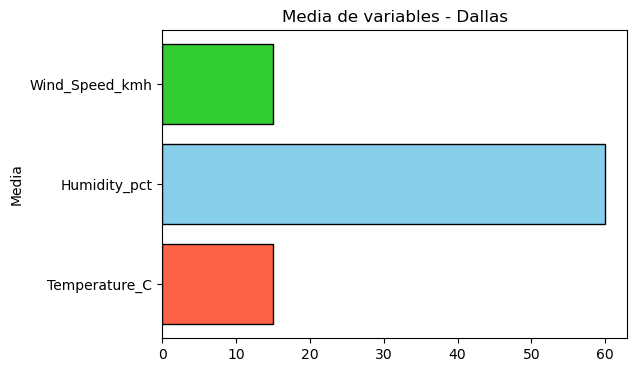

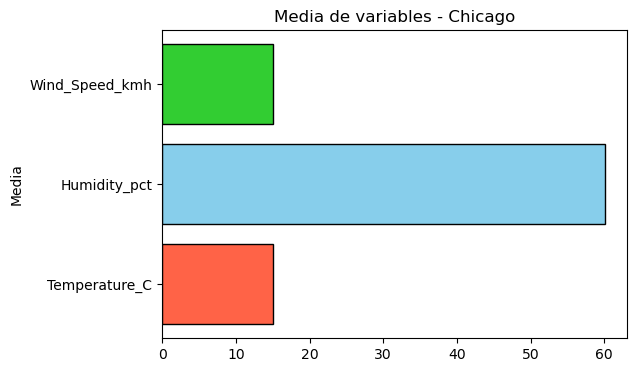

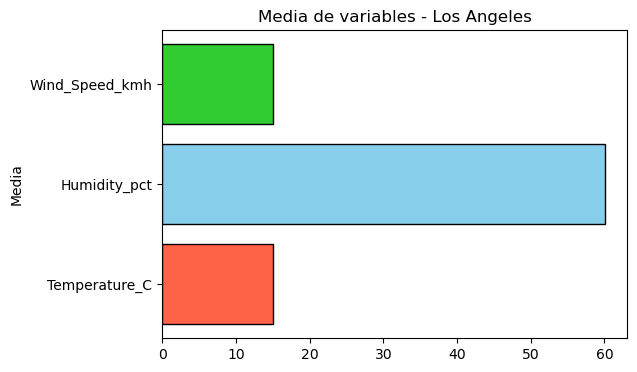

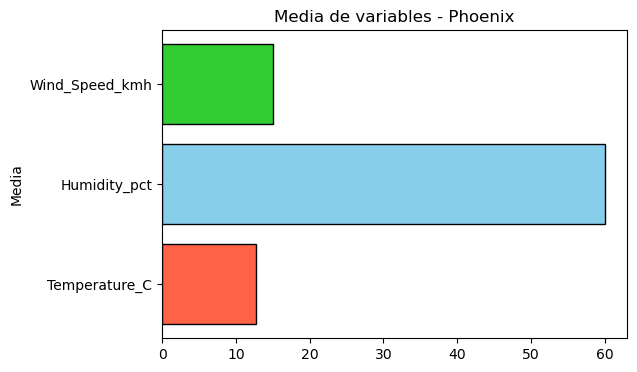

In [21]:
def grafico_barras(df, location, variable1, variable2, variable3):

    # Obtener las ubicaciones únicas
    ubicaciones = df[location].unique()

    for locacion in ubicaciones:

        # Filtrar el DataFrame para esa ubicación
        datos = df[df[location] == locacion]

        medias = [
            datos[variable1].mean(),
            datos[variable2].mean(),
            datos[variable3].mean()
        ]

        nombres = [variable1, variable2, variable3]

        colores = ['tomato', 'skyblue', 'limegreen']

        plt.figure(figsize=(6,4))
        plt.barh(nombres, medias, color=colores, edgecolor='black')
        plt.title(f"Media de variables - {locacion}")
        plt.ylabel("Media")
        plt.show()

grafico_barras(df_clima,"Location","Temperature_C","Humidity_pct","Wind_Speed_kmh")

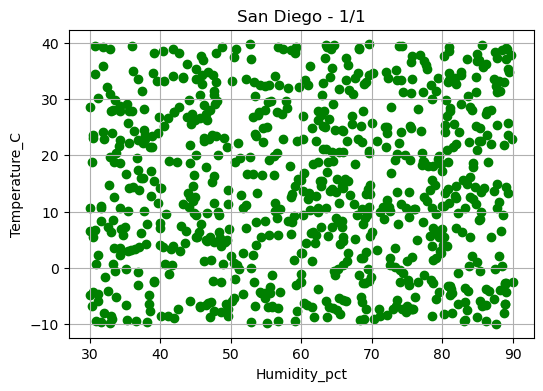

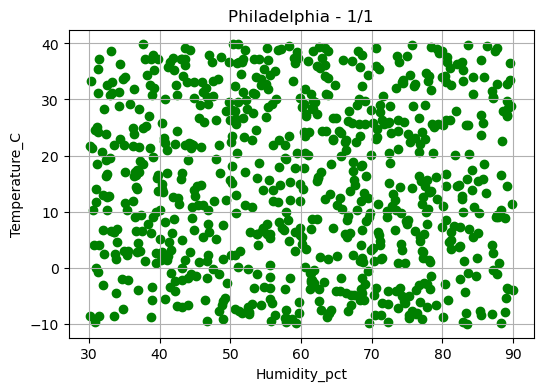

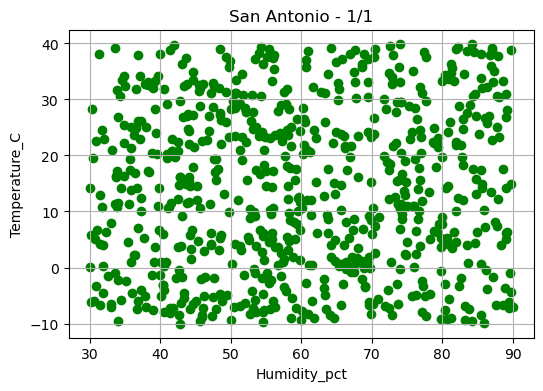

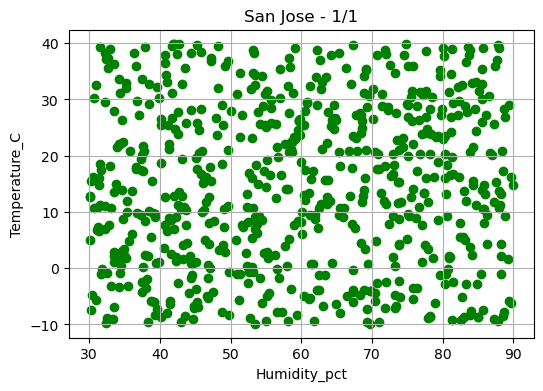

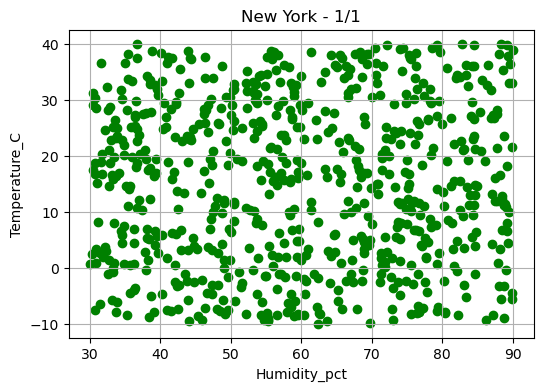

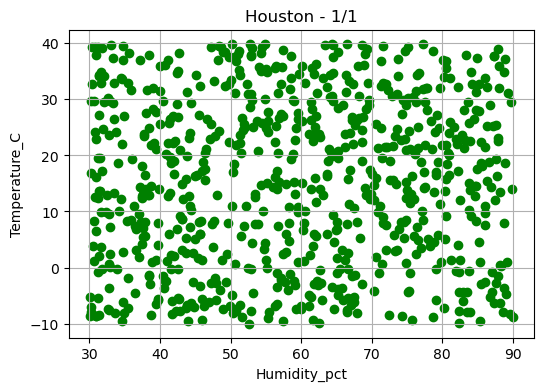

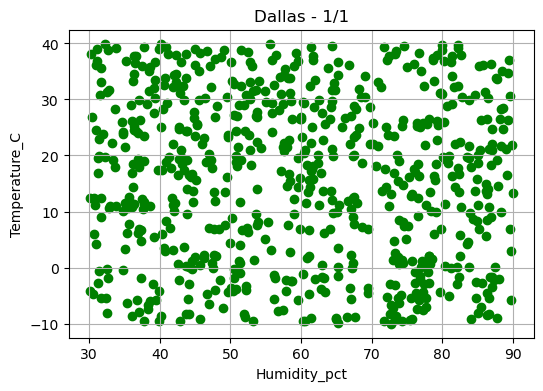

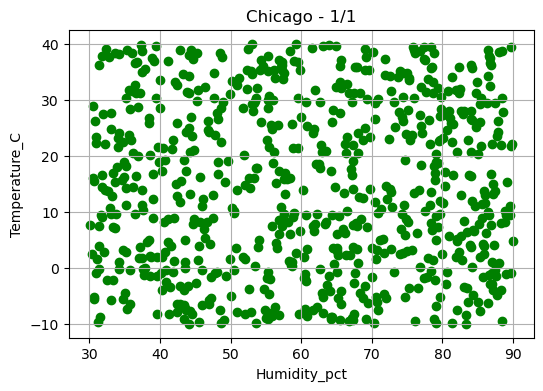

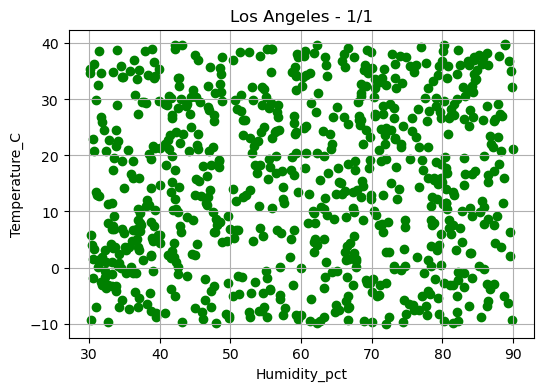

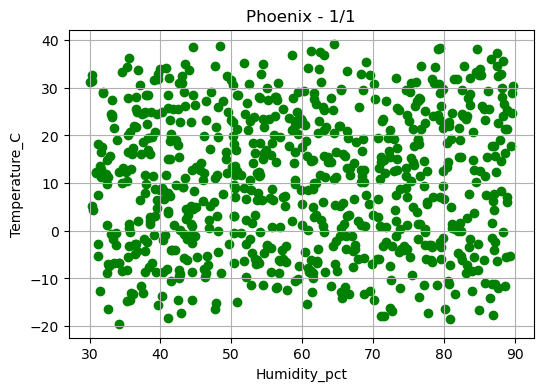

In [22]:
def dispersion_ciudad_fecha(df, location, fecha, mes, dia, x, y):

    # Recorrer todas las ciudades
    for ciudad in df[location].unique():

        # Filtrar por ciudad
        datos_c = df[df[location] == ciudad]

        # Filtrar por mes
        datos_m = datos_c[datos_c[fecha].dt.month == mes]

        # Filtrar por día
        datos_d = datos_m[datos_m[fecha].dt.day == dia]

        # Gráfico de dispersión
        plt.figure(figsize=(6,4))
        plt.scatter(datos_d[x], datos_d[y], color="green")

        plt.title(f"{ciudad} - {dia}/{mes}")
        plt.xlabel(x)
        plt.ylabel(y)
        plt.grid(True)

        plt.show()
#Llamar a la función
dispersion_ciudad_fecha(df_clima, "Location", 'Date_Time', 1, 1, "Humidity_pct","Temperature_C")

## <font color="firebrick">4. Resultados</font>

**Carga del conjunto de datos:** El conjunto de datos climáticos fue importado correctamente desde un archivo CSV. La base de datos estuvo conformada por 1 000 000 registros y 6 variables, correspondientes a la localidad, fecha y hora del registro, temperatura, humedad relativa, precipitación y velocidad del viento. La inspección inicial mostró que las variables climáticas fueron almacenadas como datos numéricos de tipo float64, mientras que las columnas Location y Date_Time fueron identificadas inicialmente como cadenas de texto

**Limpieza de datos:** Durante el proceso de depuración no se identificaron registros duplicados, por lo que el tamaño del conjunto de datos permaneció en 1 000 000 filas y 6 columnas. Asimismo, no se detectaron valores nulos en ninguna de las variables, lo que indica que la base de datos presenta un alto nivel de integridad. Finalmente, la columna Date_Time fue convertida al tipo de dato datetime, facilitando el análisis temporal de la información.

**Cálculo de la sensación térmica:** Se incorporó una nueva variable denominada Sensación_Térmica, calculada a partir de la temperatura y la humedad relativa utilizando la metodología propuesta por la NOAA. El mayor valor de sensación térmica fue de 94,36 °C, registrado en San Antonio el 7 de febrero de 2024, asociado a una temperatura de 39,99 °C y una humedad relativa cercana al 90%, mientras que la menor sensación térmica observada fue de −22,36 °C, correspondiente a la ciudad de Phoenix, registrada el 24 de enero de 2024, con una temperatura de −19,95 °C y una humedad relativa de aproximadamente 43%.

**Estadística descriptiva:** La estadística descriptiva muestra que la temperatura promedio registrada fue de 14,78 °C, con valores comprendidos entre −19,97 °C y 40,00 °C. La humedad relativa presentó un promedio de 60,02 %, mientras que la precipitación media fue de 5,11 mm y la velocidad promedio del viento alcanzó 15,00 km/h. Respecto a la variable creada, la sensación térmica registró un valor promedio de 16,74 °C, con un mínimo de −22,36 °C y un máximo de 94,36 °C, lo que evidencia una mayor variabilidad respecto a la temperatura del aire debido al efecto de la humedad.

**Identificación de tipos de datos:** El conjunto de datos final estuvo conformado por una variable categórica (Location), una variable temporal (Date_Time) y cinco variables numéricas de tipo float64.

**Validación de localidades:** Se realizó una validación mediante una lista de ciudades para verificar la presencia de determinadas localidades dentro del conjunto de datos. Como resultado, se confirmó la existencia de las ciudades Phoenix, Chicago, Philadelphia, Houston, New York, San Antonio, Dallas, Los Angeles, San Jose y San Diego. En contraste, las ciudades Madrid, Quito y Tokio no forman parte de la base de datos analizada.

**Distribución de frecuencias:** La mayor cantidad de temperaturas se concentra entre −4,98 °C y 25,01 °C, representando cerca del 60 % de los registros.
La humedad relativa presenta una distribución prácticamente uniforme entre los cuatro intervalos analizados.
La precipitación se concentra principalmente entre 0 y 7,49 mm, mientras que los eventos superiores a 11,23 mm representan una pequeña proporción del total.
La velocidad del viento presenta una distribución homogénea en los cuatro rangos definidos.
La mayor parte de las sensaciones térmicas se ubican entre −22,48 °C y 36,00 °C, siendo poco frecuentes los valores superiores a 65 °C.

**Promedios mensuales:** El análisis por mes mostró un comportamiento relativamente estable de las variables climáticas durante el período evaluado. Mayo registró la mayor temperatura promedio (15,04 °C), mientras que enero presentó la mayor precipitación media (5,26 mm). La humedad relativa y la velocidad del viento mostraron variaciones mínimas entre los diferentes meses, con promedios cercanos al 60 % y 15 km/h, respectivamente.

**Estadísticas agregadas y tendencias:** *Por localidad* Las estadísticas agrupadas por ciudad evidencian que la mayoría de las localidades presentan valores promedio muy similares para temperatura, humedad, precipitación y velocidad del viento. Sin embargo, Phoenix se diferencia al registrar la menor temperatura promedio (12,79 °C) y el mayor promedio de precipitación (6,09 mm), mientras que Los Angeles presentó la temperatura media más alta (15,08 °C). La velocidad promedio del viento fue muy similar entre todas las ciudades, con valores cercanos a 15 km/h. 

*Estadísticas generales* La temperatura varía entre −19,97 °C y 40,00 °C, con un promedio de 14,78 °C.
La humedad relativa oscila entre 30 % y 90 %, con un promedio de 60,02 %.
La precipitación presenta valores entre 0 y 14,97 mm, con un promedio de 5,11 mm.
La velocidad del viento alcanza un máximo de 30 km/h y un promedio de 15 km/h.
La sensación térmica registra un rango comprendido entre −22,36 °C y 94,36 °C.

*Tendencias climáticas* Mayo fue el mes con la mayor temperatura promedio (15,04 °C).
Enero registró la mayor precipitación acumulada del período (1 174 627,64 mm).
San Diego presentó la mayor velocidad promedio del viento (15,04 km/h), aunque la diferencia respecto al resto de ciudades fue mínima.

**Distribución general y outliers:** Las cuatro variables numéricas muestran distribuciones muy simétricas, sin outliers relevantes según el criterio de rango intercuartílico: Temperatura (-20°C a 40°C, media 14.8°C), Humedad (30% a 90%, media 60%), Precipitación (0 a 15 mm, media 5.1 mm) y Velocidad del viento (0 a 30 km/h, media 15 km/h). Los boxplots prácticamente no muestran puntos fuera de los bigotes, lo cual sugiere que los datos fueron generados dentro de rangos fijos (probablemente de forma sintética/uniforme), más que reflejar variabilidad climática real con eventos extremos. Con excepción de la sensación térmica, en donde hay outliers y se concentran exactamente donde coinciden temperatura muy alta y humedad muy alta simultáneamente.

**Velocidad del viento promedio por mes:** La velocidad promedio del viento se mantiene prácticamente constante a lo largo de los cinco meses, oscilando entre 14.98 km/h y 15.03 km/h. No existe un patrón estacional visible: el viento de enero es casi idéntico al de mayo, lo que indica que esta variable no depende del mes.

**Temperatura por ciudad:** Nueve de las diez ciudades presentan temperaturas medias muy similares, todas alrededor de 14.9°C a 15.1°C (Los Ángeles la más alta con 15.08°C, San Diego y Houston entre las más bajas de ese grupo con 14.9°C). El dato más llamativo es Phoenix, que rompe el patrón con una media de solo 12.79°C, notablemente más baja que el resto. Al desagregar por mes se ve que la diferencia se concentra en enero y febrero, donde Phoenix registra una media de 10°C, mientras que de marzo en adelante converge a los 15°C, similar al resto de ciudades, es decir, anomalía puntual en los dos primeros meses, no un patrón estacional natural.

**Precipitación mensual por ciudad:** Las precipitaciones totales por mes son muy parecidas entre ciudades (entre 63,000 y 113,000 mm acumulados según el mes), con un total acumulado de 499,000 a 501,000 mm por ciudad en el periodo. Por otro lado, Phoenix, que acumula 610,000 mm en total, muy por encima del resto. Esa diferencia se concentra exclusivamente en enero y febrero (Phoenix promedia 7.5 mm/registro esos meses, contra 5 mm/registro en el resto de ciudades y en los meses siguientes de la propia Phoenix). Es la misma anomalía detectada en temperatura: Phoenix tiene un comportamiento distinto solo en los dos primeros meses del periodo.

**Humedad promedio por mes y ciudad:** La humedad es la variable más estable de todas: en las diez ciudades y en los cinco meses se mantiene siempre alrededor del 60% (variaciones mínimas entre 59.8% y 60.3%). No hay diferencias relevantes entre ciudades ni estacionalidad.

**Medias comparadas por ciudad: temperatura, humedad y viento:** Al graficar las tres variables juntas por ciudad, el patrón se confirma: humedad (60%) y viento (15 km/h) son virtualmente idénticos en las diez ciudades, mientras que temperatura es la única variable con una diferencia visible, y nuevamente es Phoenix la que se aparta del grupo con su media de 12.8°C.

**Dispersión humedad vs. temperatura por ciudad:** Los diagramas de dispersión no muestran ninguna relación lineal entre humedad y temperatura en ninguna ciudad: las correlaciones calculadas para el 1 de enero van de -0.07 a 0.09 (prácticamente cero), y a nivel de todo el dataset la correlación global es -0.001. Lo mismo ocurre entre el resto de pares de variables (temperatura-viento: -0.001; humedad-viento: -0.0006; temperatura-precipitación: -0.01). Por ende, los puntos se ven como una nube dispersa sin ninguna tendencia ni agrupamiento, lo que es consistente con variables generadas de forma independiente entre sí.

## <font color="firebrick">5. Conclusiones</font>

1. El análisis exploratorio permitió verificar que el conjunto de datos posee una estructura consistente y una adecuada calidad de la información, al no presentar registros duplicados ni valores faltantes. Esto garantiza que los análisis estadísticos y las transformaciones aplicadas se realizaron sobre una base de datos íntegra y confiable, reduciendo el riesgo de sesgos asociados a problemas de calidad de datos.

2. La incorporación de la variable sensación térmica evidenció que la percepción del calor o del frío no depende únicamente de la temperatura ambiente, sino también de la humedad relativa. En consecuencia, esta nueva variable aporta información complementaria que permite caracterizar de forma más realista las condiciones climáticas y resulta más representativa que el uso exclusivo de la temperatura.

3. La distribución de las variables climáticas mostró un comportamiento altamente uniforme entre la mayoría de las ciudades y durante los meses analizados. La estabilidad observada en la humedad relativa, la velocidad del viento y, en menor medida, en la temperatura y la precipitación, indica que el conjunto de datos presenta una variabilidad limitada y un comportamiento homogéneo entre localidades.

4. El análisis comparativo permitió identificar a Phoenix como la única localidad que presenta un comportamiento diferente al resto, caracterizado por temperaturas promedio menores y mayores niveles de precipitación durante los dos primeros meses del período. Al concentrarse estas diferencias únicamente en enero y febrero, se concluye que corresponden a una anomalía puntual dentro del conjunto de datos y no a una tendencia climática sostenida.

5. La ausencia de valores atípicos relevantes y las distribuciones prácticamente simétricas de las variables, junto con la inexistencia de correlaciones significativas entre temperatura, humedad, precipitación y velocidad del viento, sugieren que los datos fueron generados bajo rangos previamente definidos y con independencia entre variables. Por ello, el conjunto de datos resulta apropiado para fines académicos, desarrollo de algoritmos y ejercicios de análisis exploratorio, aunque presenta limitaciones para representar la complejidad y la variabilidad propia de los registros climáticos reales.

6. En conjunto, el EDA permitió comprender la estructura, distribución y comportamiento de las variables climáticas antes de realizar análisis más avanzados. Este proceso facilitó la detección de patrones generales, la identificación de comportamientos particulares y la validación de la calidad del conjunto de datos, proporcionando una base sólida para posteriores etapas de modelado, análisis estadístico o aprendizaje automático.

## <font color="firebrick">6. Recomendaciones</font>

En futuros estudios se recomienda mantener una etapa de limpieza y validación de los datos antes de realizar cualquier análisis, ya que este proceso permite identificar posibles inconsistencias, corregir los tipos de datos y asegurar la confiabilidad de los resultados obtenidos.

Se recomienda mantener el uso de funciones personalizadas para automatizar el proceso de limpieza, transformación y análisis de los datos, facilitando la reproducibilidad del estudio y su aplicación a otros conjuntos de datos climáticos de características similares.

## <font color="firebrick">7. Referencias bibliográficas</font>

McKinney, W. (2022). Python for Data Analysis: Data Wrangling with pandas, NumPy, and Jupyter (3rd ed.). O'Reilly Media.

Heat Index equation. (2022). https://www.wpc.ncep.noaa.gov/html/heatindex_equation.shtml

Pandas Development Team. (2025). pandas documentation. https://pandas.pydata.org/docs/